# Week 4: EDA & Preprocessing Part 2

**Deliverable:** Feature engineering, train/val/test split, and preprocessing pipelines

This notebook demonstrates the preprocessing pipeline developed for Week 4:
1. Feature engineering (age buckets, interactions, encoding)
2. Train/validation/test split
3. Preprocessing pipelines
4. Cleaned dataset generation

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Import preprocessing modules
import preprocessing_config as config
from preprocessing_utils import (
    FeatureEngineer,
    DataSplitter,
    PreprocessingPipeline,
    handle_missing_values
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Load Raw Data

In [2]:
# Load raw data
df_raw = pd.read_csv(config.RAW_DATA_PATH)

print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumns: {list(df_raw.columns)}")

df_raw.head()

Dataset shape: 10000 rows × 16 columns

Columns: ['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [3]:
# Check for missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

print("Missing values:")
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

Missing values:
               Missing Count  Percentage
Health_Issues           5941       59.41


## 3. Feature Engineering

We'll create several types of engineered features:
- **Age buckets**: Categorical age groups
- **Interaction features**: Products of related features
- **Ratio features**: Meaningful ratios
- **Encoding**: Frequency and one-hot encoding for categoricals

In [4]:
# Handle missing values first
df = handle_missing_values(df_raw)

print(f"✓ Missing values handled")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

[Missing Values] Handling missing data
  Filled Health_Issues with 'Mild'
  Missing values: 5941 → 0
✓ Missing values handled
Remaining nulls: 0


In [5]:
# Initialize feature engineer
fe = FeatureEngineer(verbose=True)

# Create age buckets
df = fe.create_age_buckets(df, bins=config.AGE_BINS, labels=config.AGE_LABELS)

print("\nAge bucket distribution:")
print(df['Age_Bucket'].value_counts().sort_index())

[FeatureEngineer] Creating age buckets: ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

Age bucket distribution:
Age_Bucket
18-25    2037
26-35    2971
36-45    2978
46-55    1537
56-65     409
65+        68
Name: count, dtype: int64


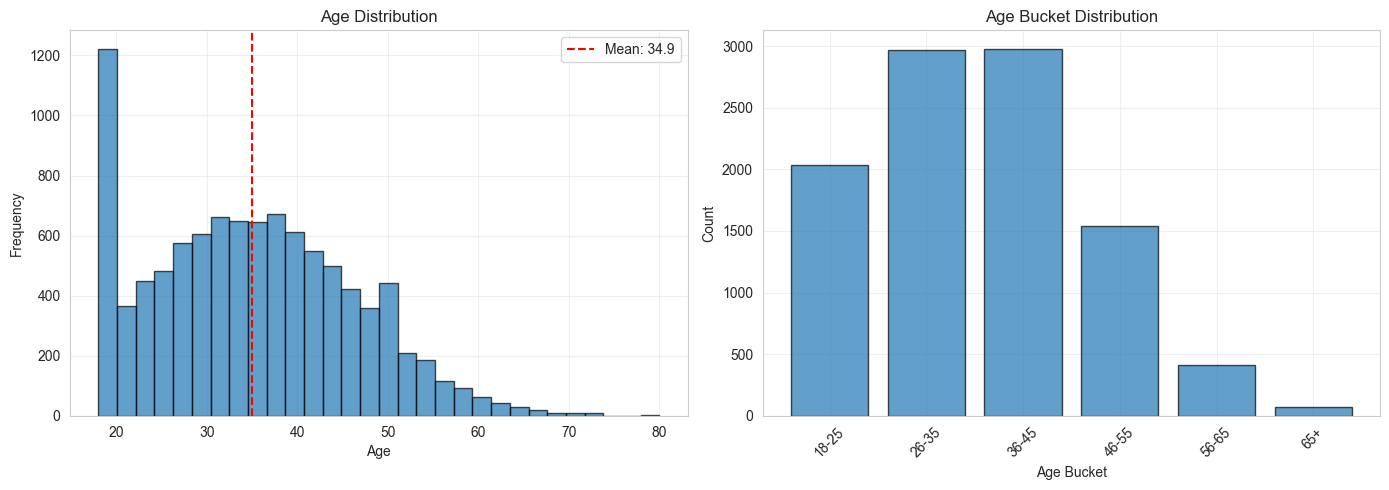

In [6]:
# Visualize age buckets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(df['Age'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Age buckets
age_counts = df['Age_Bucket'].value_counts().sort_index()
axes[1].bar(range(len(age_counts)), age_counts.values, edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=45)
axes[1].set_xlabel('Age Bucket')
axes[1].set_ylabel('Count')
axes[1].set_title('Age Bucket Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Create ratio features
df = fe.create_ratio_features(df, config.RATIO_FEATURES)

print("\nRatio features created:")
for _, _, name in config.RATIO_FEATURES:
    if name in df.columns:
        print(f"  {name}: mean={df[name].mean():.3f}, std={df[name].std():.3f}")

[FeatureEngineer] Creating 4 ratio features
[FeatureEngineer]   Created: caffeine_per_cup
[FeatureEngineer]   Created: sleep_per_cup
[FeatureEngineer]   Created: activity_age_ratio
[FeatureEngineer]   Created: bmi_activity_ratio

Ratio features created:
  caffeine_per_cup: mean=7069.718, std=150120.889
  sleep_per_cup: mean=389834.133, std=1630979.570
  activity_age_ratio: mean=0.239, std=0.166
  bmi_activity_ratio: mean=65138.662, std=1267711.586


In [8]:
# Create interaction features (numeric only)
numeric_interactions = [
    (f1, f2) for f1, f2 in config.INTERACTION_PAIRS
    if f1 in config.NUMERIC_FEATURES and f2 in config.NUMERIC_FEATURES
]

df = fe.create_interaction_features(df, numeric_interactions)

print(f"\n✓ Created {len(numeric_interactions)} interaction features")

[FeatureEngineer] Creating 5 interaction features
[FeatureEngineer]   Created: Coffee_Intake_x_Caffeine_mg
[FeatureEngineer]   Created: Coffee_Intake_x_Sleep_Hours
[FeatureEngineer]   Created: BMI_x_Physical_Activity_Hours
[FeatureEngineer]   Created: Caffeine_mg_x_Heart_Rate
[FeatureEngineer]   Created: Age_x_Coffee_Intake

✓ Created 5 interaction features


In [9]:
# Encode target variables
df = fe.encode_target_labels(df, config.TARGET_COLUMNS)

# Frequency encoding
df = fe.frequency_encoding(df, config.HIGH_CARDINALITY_FEATURES)

# One-hot encoding
df = fe.onehot_encoding(df, config.LOW_CARDINALITY_FEATURES)

print(f"\n✓ Encoding complete")
print(f"New shape: {df.shape[0]} rows × {df.shape[1]} columns")

[FeatureEngineer] Encoding 3 target variables
[FeatureEngineer]   Sleep_Quality: {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3}
[FeatureEngineer]   Stress_Level: {'High': 0, 'Low': 1, 'Medium': 2}
[FeatureEngineer]   Health_Issues: {'Mild': 0, 'Moderate': 1, 'Severe': 2}
[FeatureEngineer] Applying frequency encoding to 2 columns
[FeatureEngineer]   Encoded: Country (20 unique values)
[FeatureEngineer]   Encoded: Occupation (5 unique values)
[FeatureEngineer] Applying one-hot encoding to 1 columns
[FeatureEngineer]   Encoded: Gender (2 new columns)

✓ Encoding complete
New shape: 10000 rows × 33 columns


In [10]:
# Feature engineering summary
original_cols = set(df_raw.columns)
new_cols = set(df.columns) - original_cols

print(f"Feature Engineering Summary:")
print(f"  Original features: {len(original_cols)}")
print(f"  New features: {len(new_cols)}")
print(f"  Total features: {len(df.columns)}")

print(f"\nNew features created:")
for feat in sorted(new_cols):
    print(f"  - {feat}")

Feature Engineering Summary:
  Original features: 16
  New features: 17
  Total features: 33

New features created:
  - Age_Bucket
  - Age_x_Coffee_Intake
  - BMI_x_Physical_Activity_Hours
  - Caffeine_mg_x_Heart_Rate
  - Coffee_Intake_x_Caffeine_mg
  - Coffee_Intake_x_Sleep_Hours
  - Country_freq
  - Gender_Male
  - Gender_Other
  - Health_Issues_encoded
  - Occupation_freq
  - Sleep_Quality_encoded
  - Stress_Level_encoded
  - activity_age_ratio
  - bmi_activity_ratio
  - caffeine_per_cup
  - sleep_per_cup


## 4. Train/Validation/Test Split

Split the data into:
- **Train**: 70% (for model training)
- **Validation**: 15% (for hyperparameter tuning)
- **Test**: 15% (for final evaluation)

In [11]:
# Split data
splitter = DataSplitter(
    train_size=config.TRAIN_SIZE,
    val_size=config.VAL_SIZE,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE
)

train_df, val_df, test_df = splitter.split(df, stratify_col=config.STRATIFY_COLUMN)

print(f"\n✓ Data split complete")

Splitting data: 70% train / 15% val / 15% test
  Filtered to 10000 rows for stratification on 'Sleep_Quality'
  Train: 7000 samples
  Val:   1500 samples
  Test:  1500 samples

✓ Data split complete


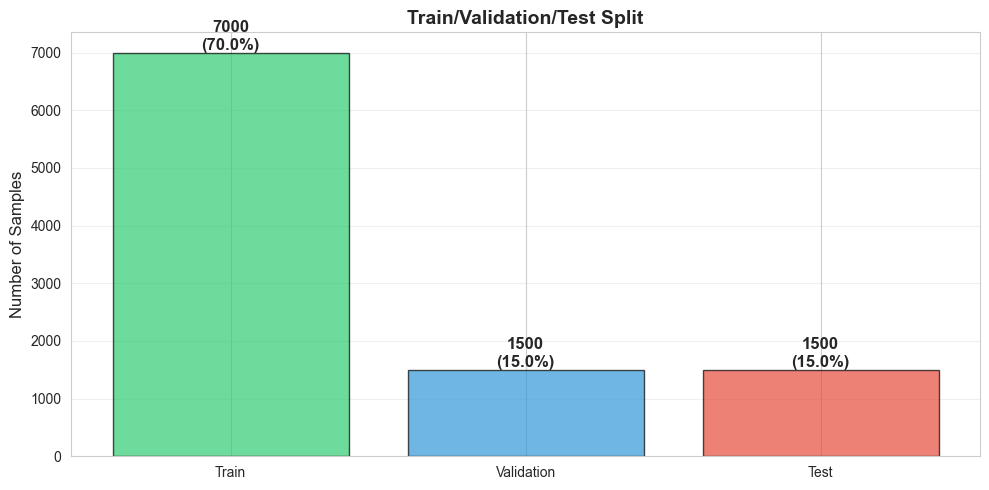

In [12]:
# Visualize split
fig, ax = plt.subplots(figsize=(10, 5))

splits = ['Train', 'Validation', 'Test']
counts = [len(train_df), len(val_df), len(test_df)]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(splits, counts, color=colors, alpha=0.7, edgecolor='black')

# Add count labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Train/Validation/Test Split', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

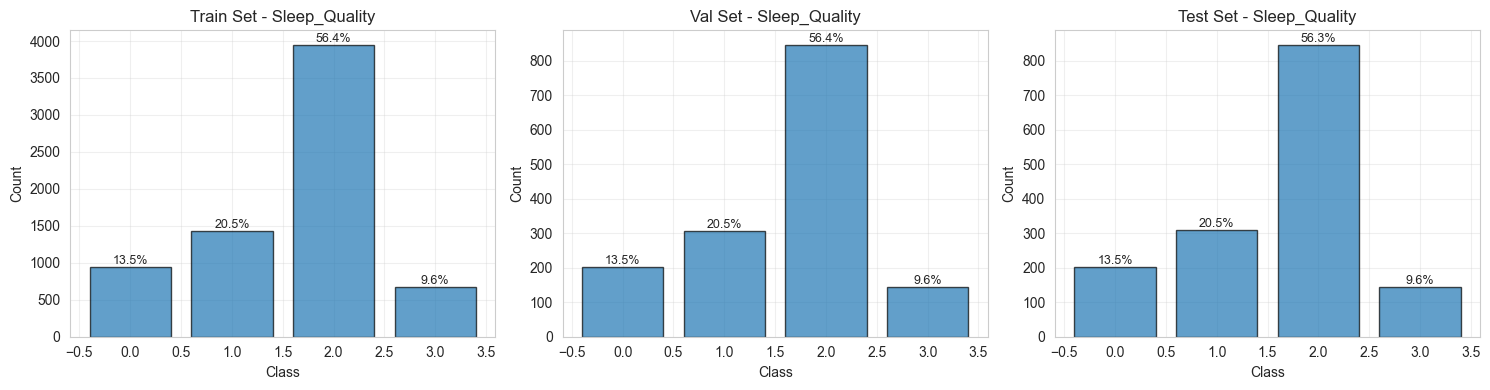

In [13]:
# Check target distribution across splits
target_col_encoded = config.STRATIFY_COLUMN + '_encoded'

if target_col_encoded in train_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (name, data) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
        counts = data[target_col_encoded].value_counts().sort_index()
        ax.bar(counts.index, counts.values, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Class')
        ax.set_ylabel('Count')
        ax.set_title(f'{name} Set - {config.STRATIFY_COLUMN}')
        ax.grid(alpha=0.3)
        
        # Add percentages
        total = len(data)
        for i, count in enumerate(counts.values):
            ax.text(i, count, f'{count/total*100:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 5. Preprocessing & Scaling

Apply standardization to numeric features:
- Fit scaler on training data
- Transform all splits using fitted scaler

In [14]:
# Identify numeric columns for scaling
all_numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude ID and encoded targets
exclude_patterns = ['_encoded', 'ID']
numeric_cols_to_scale = [
    col for col in all_numeric_cols
    if not any(pattern in col for pattern in exclude_patterns)
]

print(f"Scaling {len(numeric_cols_to_scale)} numeric features")
print(f"Features: {numeric_cols_to_scale[:10]}..." if len(numeric_cols_to_scale) > 10 else f"Features: {numeric_cols_to_scale}")

Scaling 20 numeric features
Features: ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Heart_Rate', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption', 'caffeine_per_cup']...


In [15]:
# Initialize and apply preprocessing pipeline
pipeline = PreprocessingPipeline(scaling_method=config.SCALING_METHOD)

# Fit on train and transform all
train_scaled = pipeline.fit_transform(train_df, numeric_cols_to_scale)
val_scaled = pipeline.transform(val_df)
test_scaled = pipeline.transform(test_df)

print(f"\n✓ Scaling complete using {config.SCALING_METHOD} method")

[Pipeline] Fitting standard scaler on 20 numeric features
[Pipeline] Scaling complete
[Pipeline] Transforming data with fitted scaler
[Pipeline] Transforming data with fitted scaler

✓ Scaling complete using standard method


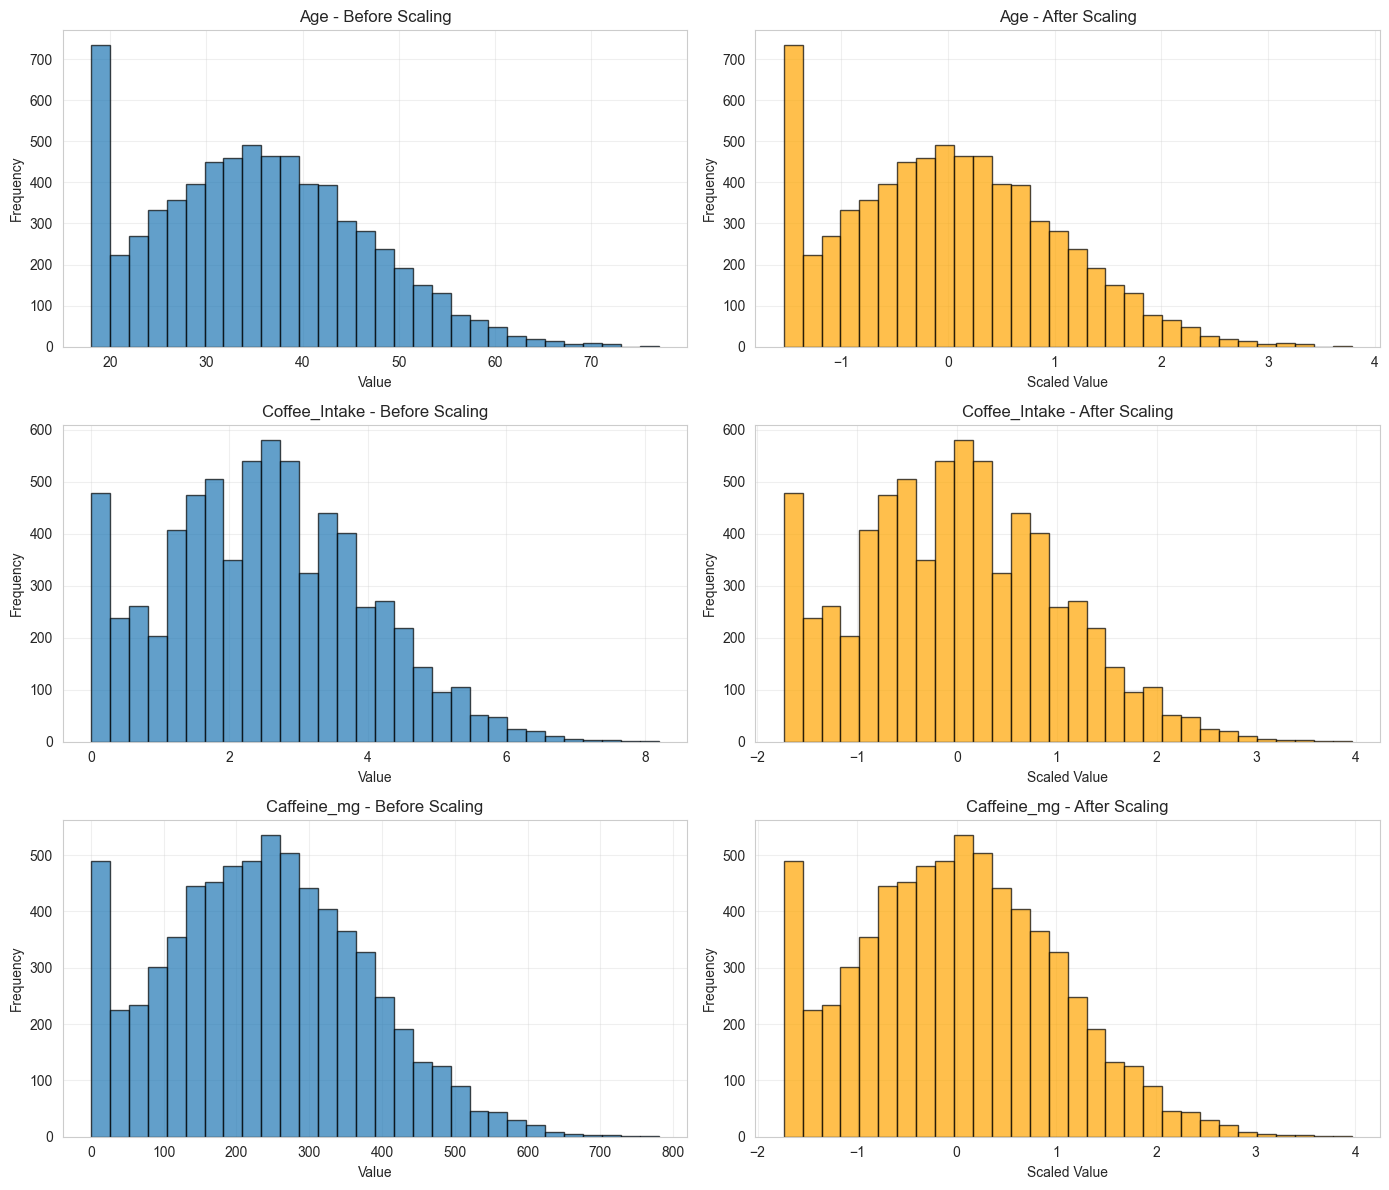

In [16]:
# Visualize scaling effect
sample_features = numeric_cols_to_scale[:3]  # First 3 numeric features

fig, axes = plt.subplots(len(sample_features), 2, figsize=(14, 4*len(sample_features)))

for i, feat in enumerate(sample_features):
    # Before scaling
    axes[i, 0].hist(train_df[feat], bins=30, alpha=0.7, edgecolor='black')
    axes[i, 0].set_title(f'{feat} - Before Scaling')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(alpha=0.3)
    
    # After scaling
    axes[i, 1].hist(train_scaled[feat], bins=30, alpha=0.7, edgecolor='black', color='orange')
    axes[i, 1].set_title(f'{feat} - After Scaling')
    axes[i, 1].set_xlabel('Scaled Value')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [17]:
# Create output directory
config.PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save datasets
train_scaled.to_csv(config.TRAIN_DATA_PATH, index=False)
val_scaled.to_csv(config.VAL_DATA_PATH, index=False)
test_scaled.to_csv(config.TEST_DATA_PATH, index=False)

# Save feature-engineered (pre-split) data
df.to_csv(config.FEATURE_ENGINEERED_PATH, index=False)

print("✓ Saved processed datasets:")
print(f"  - {config.TRAIN_DATA_PATH}")
print(f"  - {config.VAL_DATA_PATH}")
print(f"  - {config.TEST_DATA_PATH}")
print(f"  - {config.FEATURE_ENGINEERED_PATH}")

✓ Saved processed datasets:
  - c:\Users\hmeln\source\repos\DS-Research-NS\data\processed\train.csv
  - c:\Users\hmeln\source\repos\DS-Research-NS\data\processed\val.csv
  - c:\Users\hmeln\source\repos\DS-Research-NS\data\processed\test.csv
  - c:\Users\hmeln\source\repos\DS-Research-NS\data\processed\features_engineered.csv


## 7. Summary & Next Steps

In [18]:
print("=" * 80)
print("WEEK 4 PREPROCESSING SUMMARY")
print("=" * 80)

print(f"\n1. FEATURE ENGINEERING")
print(f"   - Original features: {len(df_raw.columns)}")
print(f"   - Engineered features: {len(df.columns) - len(df_raw.columns)}")
print(f"   - Total features: {len(df.columns)}")

print(f"\n2. DATA SPLITTING")
print(f"   - Train: {len(train_scaled)} samples ({len(train_scaled)/len(df)*100:.1f}%)")
print(f"   - Val:   {len(val_scaled)} samples ({len(val_scaled)/len(df)*100:.1f}%)")
print(f"   - Test:  {len(test_scaled)} samples ({len(test_scaled)/len(df)*100:.1f}%)")

print(f"\n3. PREPROCESSING")
print(f"   - Scaling method: {config.SCALING_METHOD}")
print(f"   - Scaled features: {len(numeric_cols_to_scale)}")
print(f"   - Missing values handled: ✓")

print(f"\n4. TARGET VARIABLES")
for target_name, target_col in config.TARGET_COLUMNS.items():
    encoded_col = f"{target_col}_encoded"
    if encoded_col in train_scaled.columns:
        n_classes = train_scaled[encoded_col].nunique()
        print(f"   - {target_name}: {n_classes} classes")

print(f"\n5. OUTPUT FILES")
print(f"   - Train data: {config.TRAIN_DATA_PATH.name}")
print(f"   - Val data: {config.VAL_DATA_PATH.name}")
print(f"   - Test data: {config.TEST_DATA_PATH.name}")
print(f"   - Features: {config.FEATURE_ENGINEERED_PATH.name}")

print(f"\n" + "=" * 80)
print("✓ READY FOR WEEK 5: BASELINE MODELING")
print("=" * 80)

WEEK 4 PREPROCESSING SUMMARY

1. FEATURE ENGINEERING
   - Original features: 16
   - Engineered features: 17
   - Total features: 33

2. DATA SPLITTING
   - Train: 7000 samples (70.0%)
   - Val:   1500 samples (15.0%)
   - Test:  1500 samples (15.0%)

3. PREPROCESSING
   - Scaling method: standard
   - Scaled features: 20
   - Missing values handled: ✓

4. TARGET VARIABLES
   - sleep_quality: 4 classes
   - stress_level: 3 classes
   - health_issues: 3 classes

5. OUTPUT FILES
   - Train data: train.csv
   - Val data: val.csv
   - Test data: test.csv
   - Features: features_engineered.csv

✓ READY FOR WEEK 5: BASELINE MODELING


## Next Steps (Week 5)

With the cleaned and preprocessed data ready, we can now proceed to:

1. **Train baseline models** for each target:
   - Sleep Quality prediction
   - Stress Level prediction
   - Health Issues prediction

2. **Model types to explore**:
   - Logistic Regression
   - LightGBM
   - Random Forest

3. **Evaluation metrics**:
   - Accuracy, Precision, Recall, F1
   - ROC-AUC
   - Confusion matrices

4. **Save baseline results** for comparison with future models